### Classification using Deep neural network (Any One from the following
- Multiclass classification using Deep Neural Networks: Example: Use the OCR letter
recognition dataset https://archive.ics.uci.edu/ml/datasets/letter+recognition

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [19]:
columns=['letters','x1','y1','x2','y2','x3','y3','x4','y4','x5','y5','x6','y6','x7','y7','x8','y8']

In [20]:
data = pd.read_csv('letter-recognition.csv',names=columns,header=None)
data= data.drop(index=0)
data

,letters,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,x6,y6,x7,y7,x8,y8
1,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
2,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
3,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
4,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
5,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19997,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19998,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19999,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 1 to 20000
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   letters  20000 non-null  object
 1   x1       20000 non-null  object
 2   y1       20000 non-null  object
 3   x2       20000 non-null  object
 4   y2       20000 non-null  object
 5   x3       20000 non-null  object
 6   y3       20000 non-null  object
 7   x4       20000 non-null  object
 8   y4       20000 non-null  object
 9   x5       20000 non-null  object
 10  y5       20000 non-null  object
 11  x6       20000 non-null  object
 12  y6       20000 non-null  object
 13  x7       20000 non-null  object
 14  y7       20000 non-null  object
 15  x8       20000 non-null  object
 16  y8       20000 non-null  object
dtypes: object(17)
memory usage: 2.6+ MB


In [22]:
data.isnull().sum()

letters    0
x1         0
y1         0
x2         0
y2         0
x3         0
y3         0
x4         0
y4         0
x5         0
y5         0
x6         0
y6         0
x7         0
y7         0
x8         0
y8         0
dtype: int64

In [23]:
data["letters"].value_counts()

letters
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64

In [45]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
     

encoder=LabelEncoder()
     
x=data.drop('letters',axis=1)
y=data['letters']
y_encoded=encoder.fit_transform(y)
y_catego=to_categorical(y_encoded)
x_train,x_test,y_train,y_test= train_test_split(x,y_catego,test_size=0.2,random_state=42)
     

scaler=StandardScaler()

x_train_scale= scaler.fit_transform(x_train)
x_test_scale=scaler.fit_transform(x_test)
     

#Model Build
model = Sequential([Input(shape=(x_train_scale.shape[1],)),
                    Dense(128,activation='relu'),
                    Dense(64,activation='relu'),
                    Dense(32,activation='relu'),
                    Dense(26,activation='softmax')])
model.compile('adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()
     


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,370 (52.23 KB)

 Trainable params: 13,370 (52.23 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history= model.fit(x_train_scale,y_train,epochs=50,validation_split=0.2,verbose=1)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5530 - loss: 1.5977 - val_accuracy: 0.7387 - val_loss: 0.9107
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7896 - loss: 0.7211 - val_accuracy: 0.8172 - val_loss: 0.6262
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8367 - loss: 0.5406 - val_accuracy: 0.8487 - val_loss: 0.5192
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8697 - loss: 0.4367 - val_accuracy: 0.8700 - val_loss: 0.4406
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8891 - loss: 0.3714 - val_accuracy: 0.8891 - val_loss: 0.3619
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9023 - loss: 0.3189 - val_accuracy: 0.8988 - val_loss: 0.3294
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9128 - loss: 0.2844 - val_accuracy: 0.8994 - val_loss: 0.3200
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9222 - loss: 0.2537 - val_accuracy: 0.

In [32]:
y_pred=model.predict(x_test_scale)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [33]:
pred_indices= np.argmax(y_pred,axis=1)
actual_indices=np.argmax(y_test,axis=1)

In [34]:
pred_label=encoder.inverse_transform(pred_indices)
actual_label=encoder.inverse_transform(actual_indices)

In [35]:
print("Prediction Vs Accuracy")
for i in range(5):
    print(f"Actual: {actual_label[i]}, Predicted: {pred_label[i]}")

Prediction Vs Accuracy
Actual: T, Predicted: Z
Actual: L, Predicted: L
Actual: A, Predicted: A
Actual: E, Predicted: E
Actual: Q, Predicted: Q


In [36]:
loss,accuracy= model.evaluate(x_test_scale,y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9563 - loss: 0.1793


In [38]:
print("Model loss: ",loss)
print("Model accuracy: ",accuracy)

Model loss:  0.17927320301532745
Model accuracy:  0.956250011920929


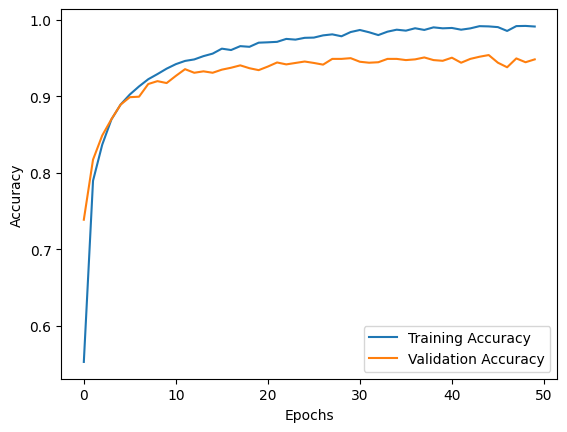

In [39]:

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show();
     


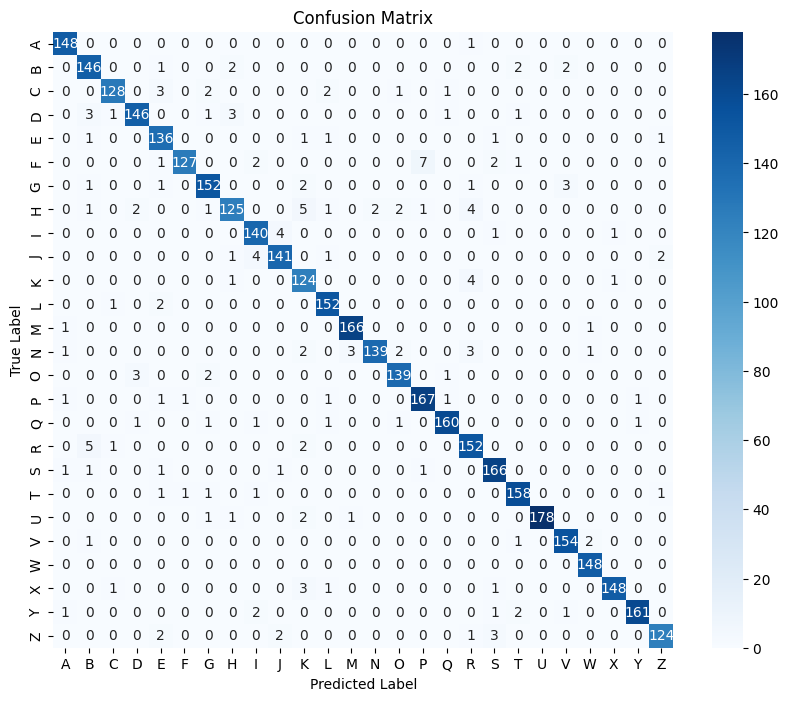

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()